# LAB1: Dataset Exploration

In [1]:
# 1. โหลดไลบรารีสำหรับจัดการข้อมูลตัวเลขและตาราง (Pandas, NumPy)
import pandas as pd
import numpy as np

# 2. โหลดไลบรารีสำหรับวาดกราฟและทำแผนภูมิความร้อน (Matplotlib, Seaborn)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. โหลดเครื่องมือแปลงข้อความเป็นตัวเลขเพื่อทำ Feature Engineering
from sklearn.preprocessing import LabelEncoder

# 4. อ่านไฟล์ข้อมูลราคาหุ้น Microsoft เข้าสู่ตัวแปรชื่อ df
df = pd.read_csv('Microsoft_stock_history.csv')
print("ดาวน์โหลดข้อมูลสำเร็จ! พร้อมทำใบงานแล้วครับ")

ดาวน์โหลดข้อมูลสำเร็จ! พร้อมทำใบงานแล้วครับ


## LAB2: Data Visualization

=== ผลการรัน LAB2: Data Visualization ===


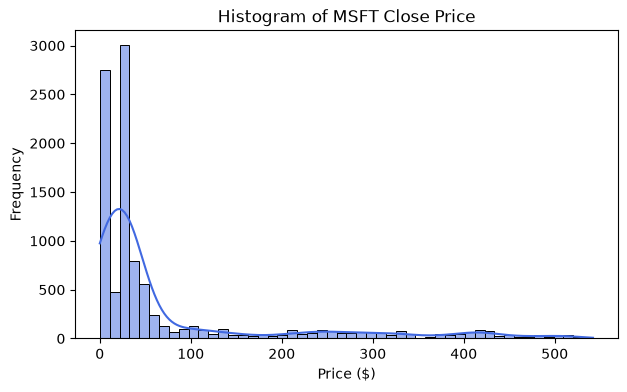

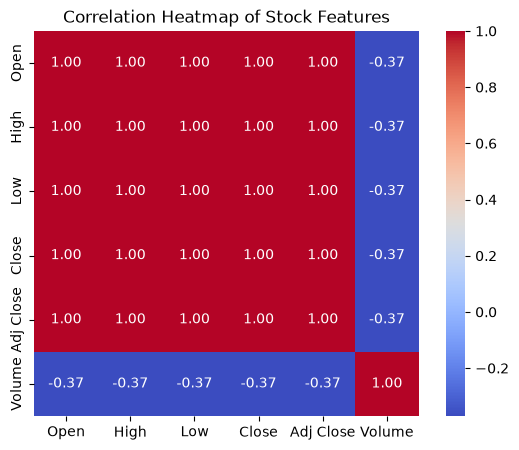

In [2]:
print("=== ผลการรัน LAB2: Data Visualization ===")

# 1. Histogram: พล็อตกราฟแท่งแสดงความถี่ เพื่อดูการกระจายตัวของราคาปิด (Close Price)
plt.figure(figsize=(7, 4)) # กำหนดขนาดรูปภาพกว้าง 7 สูง 4
sns.histplot(df['Close'], bins=50, kde=True, color='royalblue') # วาดกราฟและเส้นโค้งความถี่
plt.title('Histogram of MSFT Close Price') # ตั้งชื่อกราฟ
plt.xlabel('Price ($)') # ตั้งชื่อแกน X
plt.ylabel('Frequency') # ตั้งชื่อแกน Y
plt.show() # สั่งแสดงรูปภาพกราฟบนหน้าจอ

# 2. Correlation Heatmap: สร้างแผนภูมิความร้อนดูความสัมพันธ์ของราคาหุ้น
plt.figure(figsize=(7, 5)) # กำหนดขนาดรูปภาพ
# เลือกเฉพาะคอลัมน์ตัวเลขราคาและปริมาณการซื้อขายมาคำนวณหาค่าความสัมพันธ์ (Correlation)
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
# พล็อตแผนภูมิความร้อน ใส่ตัวเลขกำกับทศนิยม 2 ตำแหน่ง และใช้โทนสีส้ม-น้ำเงิน
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Heatmap of Stock Features') # ตั้งชื่อกราฟ
plt.show() # สั่งแสดงกราฟ Heatmap

## Part 3: Data Cleaning

In [3]:
print("=== ผลการรัน Part 3: Data Cleaning ===")

# 1. Data Type Conversion: แปลงคอลัมน์ Date จากตัวหนังสือ (Object) ให้เป็นระบบวันที่และเวลาจริง (Datetime)
df['Date'] = pd.to_datetime(df['Date'])
print("1. แปลงประเภทข้อมูลคอลัมน์ Date ให้เป็น Datetime เรียบร้อยแล้ว")

# 2. Missing Value Handling & Duplicate Removal: คำสั่งดักลบข้อมูลว่างและข้อมูลซ้ำ (เพื่อความปลอดภัยตามโจทย์)
df = df.dropna()            # ลบแถวที่เป็นค่าว่างทิ้ง (ถ้ามี)
df = df.drop_duplicates()   # ลบแถวที่ซ้ำซ้อนกันทิ้ง (ถ้ามี)
print("2. ตรวจเช็กและล้างข้อมูลว่าง/ข้อมูลซ้ำซ้อนเรียบร้อยแล้ว")

# 3. Compare Mean / Median: คำนวณหาค่าเฉลี่ยและค่ามัธยฐานเพื่อเปรียบเทียบสถิติของราคาปิด
mean_close = df['Close'].mean()     # คำนวณค่าเฉลี่ย
median_close = df['Close'].median() # คำนวณค่ากลาง (มัธยฐาน)
print(f"\n3. การเปรียบเทียบค่ากลางข้อมูลราคาปิด (Close):")
print(f"   - ค่าเฉลี่ยราคาปิด (Mean): {mean_close:.2f} ดอลลาร์")
print(f"   - ค่ามัธยฐานราคาปิด (Median): {median_close:.2f} ดอลลาร์")

=== ผลการรัน Part 3: Data Cleaning ===
1. แปลงประเภทข้อมูลคอลัมน์ Date ให้เป็น Datetime เรียบร้อยแล้ว
2. ตรวจเช็กและล้างข้อมูลว่าง/ข้อมูลซ้ำซ้อนเรียบร้อยแล้ว

3. การเปรียบเทียบค่ากลางข้อมูลราคาปิด (Close):
   - ค่าเฉลี่ยราคาปิด (Mean): 74.75 ดอลลาร์
   - ค่ามัธยฐานราคาปิด (Median): 27.86 ดอลลาร์


## Part 4: Feature Engineering

In [4]:
print("=== ผลการรัน Part 4: Feature Engineering ===")

# 1. สร้างคอลัมน์จำลอง 'Price_Trend' เพื่อบอกว่าวันนั้นหุ้นขึ้น (Up) หรือหุ้นลง (Down) 
# เงื่อนไข: ถ้าราคาปิด (Close) สูงกว่าราคาเปิด (Open) จะได้ 'Up' นอกนั้นจะได้ 'Down'
df['Price_Trend'] = np.where(df['Close'] > df['Open'], 'Up', 'Down')
print("1. สร้างคอลัมน์บอกแนวโน้ม 'Price_Trend' (Up/Down) ตัวอย่างข้อมูล 3 แถวแรก:")
print(df[['Open', 'Close', 'Price_Trend']].head(3))

# 2. Label Encoding: แปลงข้อความกลุ่มให้กลายเป็นเลขฐานอย่างง่าย (เปลี่ยน Down ให้เป็นเลข 0 และ Up ให้เป็นเลข 1)
le = LabelEncoder()
df['Trend_LabelEncoded'] = le.fit_transform(df['Price_Trend'])
print("\n2. ผลการทำ Label Encoding (Down กลายเป็น 0, Up กลายเป็น 1):")
print(df[['Price_Trend', 'Trend_LabelEncoded']].head(3))

# 3. One-Hot Encoding: กระจายคอลัมน์กลุ่มออกมาเป็นคอลัมน์เลขฐานสองแยกกัน (Trend_Down และ Trend_Up)
df = pd.get_dummies(df, columns=['Price_Trend'], prefix='Trend', dtype=int)
print("\n3. ผลการทำ One-Hot Encoding (แตกเป็นคอลัมน์ย่อยระบุด้วยเลข 0 และ 1):")
print(df[['Trend_LabelEncoded', 'Trend_Down', 'Trend_Up']].head(3))

=== ผลการรัน Part 4: Feature Engineering ===
1. สร้างคอลัมน์บอกแนวโน้ม 'Price_Trend' (Up/Down) ตัวอย่างข้อมูล 3 แถวแรก:
       Open     Close Price_Trend
0  0.088542  0.097222          Up
1  0.097222  0.100694          Up
2  0.100694  0.102431          Up

2. ผลการทำ Label Encoding (Down กลายเป็น 0, Up กลายเป็น 1):
  Price_Trend  Trend_LabelEncoded
0          Up                   1
1          Up                   1
2          Up                   1

3. ผลการทำ One-Hot Encoding (แตกเป็นคอลัมน์ย่อยระบุด้วยเลข 0 และ 1):
   Trend_LabelEncoded  Trend_Down  Trend_Up
0                   1           0         1
1                   1           0         1
2                   1           0         1


### แหล่งที่มาของข้อมูล (Data Credit)
* **Dataset:** Microsoft Stock Details - Updated Regularly
* **ผู้สร้าง/รวบรวมข้อมูล:** Kalilur Rahman (Dataset Creator)
* **แพลตฟอร์ม:** Kaggle
* **ลิงก์ข้อมูล:** https://www.kaggle.com/datasets/kalilurrahman/microsoft-stock-details-updated-regularly